## Libraries & Function

In [1]:
%matplotlib ipympl
import numpy as np
from scipy.linalg import expm
from qutip import *
import numba
from numba import njit, prange
import matplotlib.pyplot as plt
from IPython.display import Image, display, Math


In [2]:

sz = np.array(([[1,0], [0,-1]]), dtype=complex); sx = np.array(([[0,1],[1,0]]), dtype=complex); sy = np.array(([[0,-1j],[1j,0]]), dtype=complex) 


In [3]:
#funzione per plottare in LaTex delle matrici
def array_to_latex(array, real = False, array_name = None):
    array = array.real if real else array
    matrix = ''
    for row in array:
        try:
            for number in row:
                matrix += f'{number}&'
        except TypeError:
            matrix += f'{row}&'
        matrix = matrix[:-1] + r'\\'
    if array_name != None:
        display(Math(array_name+r' = \begin{bmatrix}'+matrix+r'\end{bmatrix}'))
    else:
        display(Math(r'\begin{bmatrix}'+matrix+r'\end{bmatrix}'))

### Hamiltonians and U operator

In [4]:
def system_Hamiltonian(N_site, E, V_array, mode="complete"):
    """
    Build up of the System's Hamiltonian for the complete basis (ground & excited states) or only excited states.
    
    Method: - "complete"-> complete basis (ground & excited states)
            - "exc"-> excited basis (only excited states)
    
    Parameters: - E: Float, System's Site Energies (randomly generated)
                - V_array: Float, Hopping Potential
                - N_site : Int, Number of Sites
        
    Returns : System's Hamiltonian as Numpy array
    """
    # -----------------------------------------------------
    # Build symmetric matrix from upper triangular elements
    # -----------------------------------------------------
    V_matrix = np.zeros((N_site, N_site))
    idx = 0  # runs over V_array
    for i in range(N_site):
        for j in range(i+1, N_site):
            V_matrix[i, j] = V_array[idx]
            V_matrix[j, i] = V_array[idx]  # Symmetric
            idx += 1
    
    # -------------------------
    # Only Excited States Basis
    # -------------------------
    if mode == "exc":   
        H_sys = np.zeros((N_site, N_site), dtype=complex)
        for i in range(N_site):
            H_sys[i, i] = E[i]
 
        for i in range(N_site):
            for j in range(N_site):
                if i != j:
                    H_sys[i, j] = V_matrix[i, j]
        return H_sys
        
    # --------------
    # Complete Basis 
    # --------------    
    elif mode == "complete":   
        H_sys = np.zeros((2**N_site, 2**N_site), dtype='complex')
        
        for i in range(N_site):
            H_i = (E[i]/2) * (tensor(identity(2**i), identity(2)-sigmaz(), identity(2**(N_site-i-1))))
            H_sys += H_i.full()
            
            for j in range(i+1, N_site):
               H_ij = V_matrix[i, j]/2 * (tensor(identity(2**i), sigmax(), identity(2**(j-i-1)), sigmax(), identity(2**(N_site-j-1))) + tensor(identity(2**i), sigmay(), identity(2**(j-i-1)), sigmay(), identity(2**(N_site-j-1))))
               H_sys += H_ij.full()
        
        return H_sys

    else:
        raise ValueError("mode : 'complete' or 'exc'")

In [5]:
def interaction_Hamiltonian(N_site, c_CM, g_x, g_z):   
    """
    Build up of the Hamiltonian of Interaction for the Collision System - Ancilla in both Quantum Jump and Diffusive Limit
       
    Parameters: - N_site : int, Number of Sites
                - c_CM : list, Interaction Forces for the System - Ancilla intercation/collsion
                - g_x : float, parametr for the sigma x interaction
                - g_z : float, parametr for the sigma z interaction
        
    Returns : Hamiltonian of Interaction as Qutip object
    """
    dim_tot = 2**(2 * N_site)
    H_int = np.zeros((dim_tot, dim_tot), dtype=complex)   #inizialization

    for j in range(N_site):
        # Create fresh lists for Z and X terms
        op_list_z = [qeye(2) for _ in range(2 * N_site)]
        op_list_x = [qeye(2) for _ in range(2 * N_site)]  
        
       # Z_sys tensor Z_anc
        op_list_z[j] = sigmaz()             # System j
        op_list_z[N_site + j] = sigmaz()    # Ancilla j
        
        # Z_sys tensor X_anc
        op_list_x[j] = sigmaz()             # System j
        op_list_x[N_site + j] = sigmax()    # Ancilla j 

        # Tensor product between the element of the list
        term_z = tensor(op_list_z)
        term_x = tensor(op_list_x)
        
        H_term = c_CM[j] * (g_z * term_z + g_x * term_x)  
            
        H_int += H_term.full()
    
    return H_int


In [6]:
def hamiltonian_N_ancillas(N_site, E, V_array, c_CM, g_x, g_z):
    """
    Generation of 3 Hamiltonians for the collision model with N ancillas:
                - H_system : system Hamiltonian
                - H_collision : interaction Hamiltonian with N ancillas
                - H_tot : complete Hamiltonian (system + collision)

    Parameters: - E: Float, System's Site Energies (randomly generated)
                - V_array: Float, Hopping Potential
                - N_site : int, Number of Sites
                - c_CM : list, Interaction Forces for the System - Ancilla intercation/collsion

    Returns : H_system, H_collision, H_tot
    """
    
    H_collision = interaction_Hamiltonian(N_site, c_CM, g_x, g_z) 
    
    H_system = system_Hamiltonian(N_site, E, V_array, mode="complete")
    H_system = H_system.full() if hasattr(H_system, "full") else H_system
        
    dim_anc = 2**N_site
    Id_ancillas = np.eye(dim_anc, dtype=complex)
    H_system_expanded = np.kron(H_system, Id_ancillas)  #expand H_sys in the total space
        
    H_tot = H_system_expanded + H_collision
        
    return H_system, H_collision, H_tot


In [7]:
def evolution_operator(H, dt, method='expm', hermitian=True):
    """
    Build up of the evolution operator U = exp(-i H dt) using Expm or analytic diagonalization.
   
    Parameters: - H : Qobj or nparray, System Hamiltonian
                - dt : float, Timestep
    
    Method : - "expm"-> build up of the Matrix Exponential with expm
             - "diagonalization"->  build up of the propagater U as V @(exp(-i W dt))@ V_dag with W eigenvalues and V eigenvector of the Hamiltonian 

    Returns : Evolution Operator U, 
    """
    H = H.full() if hasattr(H, "full") else np.array(H)
    
    # -----------
    # Expm method
    # -----------
    
    if method == 'expm':
        U = expm(-1j * H * dt)
        return U
        
    # ---------------
    # Diagonalization
    # ---------------
    
    elif method == 'diagonalization':
        if hermitian:
            w, V = np.linalg.eigh(H)
            V_inv = V.conj().T
        else:
            w, V = np.linalg.eig(H) 
            V_inv = np.linalg.inv(V)
                
        U_diag = np.diag(np.exp(-1j * w * dt))
        U = V @ U_diag @ V_inv
        return U, U_diag, w, V

    else:
        raise ValueError("method must be 'expm' or 'diagonalization'")


### Lindblad functions

In [8]:
def Liouvillian(H, gamma_k, L_k):
    """
    Build the Liouvillian superoperator.
    
    Parameters: - H : nparray, Hamiltonian matrix
                - gamma_k : list, Decay rates
                - L_k : list, Jump Operators
    
    Returns: - super_L : nparray, Liouvillian superoperator
    """    
    I = np.eye(H.shape[0])
    super_L = -1.j * (np.kron(I, H) - np.kron(H.T, I))
    
    for k in range(len(gamma_k)):
        super_L += gamma_k[k] * (np.kron(np.conj(L_k[k]), L_k[k]) - 0.5 * np.kron(I, np.conj(L_k[k]).T @ L_k[k]) - 0.5 * np.kron((np.conj(L_k[k]).T @ L_k[k]).T, I))
    
    return super_L


In [9]:
@njit(cache=True)
def _evolve_expm_core(super_U, rho_vec_initial, n_times):
    """
    Core evolution loop with expm method (Numba JIT)
    """
    rho_size = rho_vec_initial.shape[0]
    rho_vec_list = np.zeros((rho_size, n_times), dtype=np.complex128)
    rho_vec_list[:, 0] = rho_vec_initial
    
    for i in range(1, n_times):
        rho_vec_list[:, i] = super_U @ rho_vec_list[:, i - 1]
    
    return rho_vec_list


@njit(cache=True)
def _evolve_diagonal_core(V, V_inv, U_diag, rho_vec_initial, n_times):
    """
    Core evolution loop with diagonal method (Numba JIT)
    """
    n_states = len(U_diag)
    
    # Initial coefficients in eigenbasis
    coeff = V_inv @ rho_vec_initial
    coeff_list = np.zeros((n_states, n_times), dtype=np.complex128)
    coeff_list[:, 0] = coeff
    
    # Evolution of coefficients
    for i in range(1, n_times):
        coeff_list[:, i] = U_diag * coeff_list[:, i - 1]
    
    # Transform back to original basis
    rho_vec_list = V @ coeff_list
    
    return rho_vec_list


def Lindblad_evo(rho, H, gamma_k, L_k, times, method="expm", vectorized=True):
    """
    Evolution of the density matrix with the Lindblad Eq. (Optimized with Numba)
    
    Method: - "expm" -> propagator = expm(super_L * dt)
            - "diagonal" -> diagonalization of the super-operator
        
    Vectorized: True/False to choose the output format
    
    Parameters: - H : nparray, System Hamiltonian
                - rho : Qobj or nparray, Initial Density Matrix
                - gamma_k : list, List of Decay Rates
                - L_k : list, List of Jump Operators
                - times : array, Time array
        
    Returns : - if vectorized=True → array (N^2, Nt)
              - if vectorized=False → array (Nt, N_site, N_site)
              - if method="diagonal" also returns V, W
    """
    # Convert to NumPy
    L_k = [L.full() if hasattr(L, "full") else np.array(L, dtype=complex) for L in L_k]
    H = H.full() if hasattr(H, "full") else np.array(H, dtype=complex)
    rho = rho.full() if hasattr(rho, "full") else np.array(rho, dtype=complex)
    
    rho_shape = H.shape[0]
    dt = times[1] - times[0]
    n_times = len(times)
    
    # Build Liouvillian
    super_L = Liouvillian(H, gamma_k, L_k)
    
    # Vectorize initial state
    rho_vec = rho.reshape(rho_shape * rho_shape)
    
    # -------------
    # Expm method
    # -------------
    if method == "expm":
        # Compute propagator 
        super_U = expm(super_L * dt)
        
        # evolution loop
        rho_vec_list = _evolve_expm_core(super_U, rho_vec, n_times)
        
        # Output
        if vectorized:
            return rho_vec_list
        else:
            return rho_vec_list.T.reshape(n_times, rho_shape, rho_shape)
    
    # ------------------
    # Diagonal method
    # ------------------
    elif method == "diagonal":
        # Diagonalize Liouvillian 
        W, V = np.linalg.eig(super_L)
        V_inv = np.linalg.inv(V)
        
        # Diagonal evolution operator
        U_diag = np.exp(W * dt)
        
        # evolution loop
        rho_vec_list = _evolve_diagonal_core(V, V_inv, U_diag, rho_vec, n_times)
        
        # Output
        if vectorized:
            return rho_vec_list, V, W
        else:
            return rho_vec_list.T.reshape(n_times, rho_shape, rho_shape), V, W
    
    else:
        raise ValueError("method must be 'expm' or 'diagonal'")

### Isolated system

In [10]:
@njit(cache=True)
def _compute_trajectory_isolated_core_general(psi_initial, U_site, projectors, n_times):
    """
    Core evolution loop - general for any number of sites
    """
    N_site = projectors.shape[0]
    pop_traj = np.zeros((N_site, n_times), dtype=np.float64)
    
    # Initial populations
    for site in range(N_site):
        P_psi = projectors[site] @ psi_initial
        pop_traj[site, 0] = np.real(np.vdot(psi_initial, P_psi))
    
    # Evolution
    psi = psi_initial.copy()
    for step in range(1, n_times):
        psi = U_site @ psi
        
        for site in range(N_site):
            P_psi = projectors[site] @ psi
            pop_traj[site, step] = np.real(np.vdot(psi, P_psi))
    
    return pop_traj

def compute_trajectory_wf_isolated(N_site, times, projectors, psi_sys_initial, U_site):
    """
    Optimized isolated system evolution with Numba (works for any N_site).
    """
    # Convert to NumPy
    U_site_np = U_site.full() if hasattr(U_site, 'full') else np.array(U_site, dtype=complex)
    psi_initial_np = psi_sys_initial.full() if hasattr(psi_sys_initial, 'full') else np.array(psi_sys_initial, dtype=complex)
    
    # Flatten if needed
    if psi_initial_np.ndim > 1:
        psi_initial_np = psi_initial_np.flatten()

    # Times 
    n_times = len(times)
        
    # JIT-compiled evolution
    pop_traj_isolated = _compute_trajectory_isolated_core_general(
        psi_initial_np, U_site_np, projectors, n_times)
    
    return pop_traj_isolated


## Comparison Diffusive vs Coherent

In [11]:
def generate_comparison_operators(dt, c_j, theta=0.0):
    """
    Genera sia gli operatori Diffusivi Standard che quelli Intermedi
    per un singolo sito, dato un theta specifico (default 0 per limite diffusivo).
    """
    # --- 1. Parametri Intermedi ---
    # Per il limite diffusivo imponiamo theta = 0 -> phi = -pi/2
    phi = theta - np.pi/2
    
    # Parametri g
    g_z = np.cos(theta)    # 1.0 per theta=0
    g_x = np.sin(theta)    # 0.0 per theta=0
    g_0 = np.cos(phi/2)    #  1/sqrt(2)
    g_1 = np.sin(phi/2)    # -1/sqrt(2)

    # Calcolo parametri a0, b0 come da Eq. 61 del tuo LaTeX
    a0 = g_0 * np.cos(c_j * dt)
    b0 = (g_0 * g_z + g_1 * g_x) * np.sin(c_j * dt)

    # Probabilità Eq. 64
    P_0_exact = np.abs(a0)**2 + np.abs(b0)**2
    
    # Parametri par (definiti nel tuo codice)
    par_0 = g_0 * g_z + g_1 * g_x
    par_1 = g_0 * g_x - g_1 * g_z
    
    # Precalcolo seno e coseno
    cos_c = np.cos(c_j * dt)
    sin_c = np.sin(c_j * dt)
    
    # --- 2. Costruzione Operatori Intermedi (con correzione) ---
    norm_factor = 1.0
    if abs(theta) < 1e-6: # Se siamo nel limite diffusivo
        norm_factor = np.sqrt(2)
        
    # M0_int corrisponde all'outcome '0' (no salto/salto piccolo A)
    M0_int = norm_factor * (g_0 * cos_c * qeye(2) - 1j * par_0 * sin_c * sigmaz())
    # M1_int corrisponde all'outcome '1' (salto/salto piccolo B)
    M1_int = norm_factor * (g_1 * cos_c * qeye(2) - 1j * par_1 * sin_c * sigmaz())

    # Questi operatori ridurranno la norma del vettore, ma è corretto così.
    M0_raw = (g_0 * cos_c * qeye(2) - 1j * par_0 * sin_c * sigmaz())
    M1_raw = (g_1 * cos_c * qeye(2) - 1j * par_1 * sin_c * sigmaz())
    
    # --- 3. Costruzione Operatori Diffusivi Standard (Target) ---
    # U0 = cos - i*sin*Sz
    # U1 = cos + i*sin*Sz
    U0_std = cos_c * qeye(2) - 1j * sin_c * sigmaz()
    U1_std = cos_c * qeye(2) + 1j * sin_c * sigmaz()
    
    return M0_int, M1_int, M0_raw, M1_raw, U0_std, U1_std, P_0_exact

# --- TEST DI VERIFICA IMMEDIATO ---
dt_test = 0.01
c_test = 0.5
m0, m1, _, _, u0, u1, _ = generate_comparison_operators(dt_test, c_test, theta=0.0)

print("Verifica Operatore M0 vs U0 (Diffusivo Standard):")
diff0 = (m0 - u0).norm()
print(f"Differenza Normale: {diff0:.2e}") 

print("\nVerifica Operatore M1 vs U1 (Diffusivo Standard):")
# Nota: Qui ci aspettiamo una differenza di fase globale (-1)
# M1 avrà un segno meno davanti rispetto a U1 perché g_1 è negativo (-1/sqrt(2))
diff1 = (m1 - u1).norm()
diff1_phase = (m1 - (-1)*u1).norm() # Proviamo a flippare il segno
print(f"Differenza Diretta: {diff1:.2f} (Atteso che sia alto per via del segno)")
print(f"Differenza col segno corretto: {diff1_phase:.2e} (Deve essere zero!)")

Verifica Operatore M0 vs U0 (Diffusivo Standard):
Differenza Normale: 0.00e+00

Verifica Operatore M1 vs U1 (Diffusivo Standard):
Differenza Diretta: 4.00 (Atteso che sia alto per via del segno)
Differenza col segno corretto: 0.00e+00 (Deve essere zero!)


## Evolution

In [12]:
@njit
def compute_simultaneous_trajectories(psi_initial, U_site, 
                                      M0s, M1s,          # Operatori Intermedi (liste per siti)
                                      U0s, U1s,          # Operatori Standard (liste per siti)
                                      projectors, n_times, N_site, seeds, P_0):
    """
    Evolve due traiettorie identiche passo-passo.
    """
    N_traj = len(seeds)
    
    # Array per salvare le popolazioni (solo sito 1 per semplicità)
    pop_int = np.zeros((n_times, N_traj), dtype=np.float64)
    pop_std = np.zeros((n_times, N_traj), dtype=np.float64)
    
    # Loop sulle traiettorie
    for traj in range(N_traj):
        np.random.seed(seeds[traj])
        
        # Inizializzo due wavefunctions identiche
        psi_int = psi_initial.copy()
        psi_std = psi_initial.copy()
        
        # Salvo stato iniziale
        p_val = np.real(psi_int.conj().T @ projectors[1] @ psi_int).item() # Popolazione sito 2 (indice 1)
        pop_int[0, traj] = p_val
        pop_std[0, traj] = p_val
        
        # Loop temporale
        for t in range(1, n_times):
            
            # 1. Evoluzione Hamiltoniana (Identica)
            psi_int = U_site @ psi_int
            psi_std = U_site @ psi_std
            
            # 2. Loop sui siti per le collisioni
            for j in range(N_site):
                r = np.random.rand() # UN SOLO numero casuale per entrambi!
                
                # --- A. Logica Intermedia ---
                # Probabilità fissa a 0.5 per theta=0
                if r < P_0:
                    psi_int = M0s[j] @ psi_int
                else:
                    psi_int = M1s[j] @ psi_int
                
                # --- B. Logica Standard ---
                if r < 0.5:
                    psi_std = U0s[j] @ psi_std
                else:
                    psi_std = U1s[j] @ psi_std
            
            # 3. Normalizzazione
            norm_int = np.sqrt(np.real(psi_int.conj().T @ psi_int).item())
            psi_int = psi_int / norm_int
            
            norm_std = np.sqrt(np.real(psi_std.conj().T @ psi_std).item())
            psi_std = psi_std / norm_std
            
            # 4. Misura
            pop_int[t, traj] = np.real(psi_int.conj().T @ projectors[1] @ psi_int).item()
            pop_std[t, traj] = np.real(psi_std.conj().T @ projectors[1] @ psi_std).item()
            
    return pop_int, pop_std

In [13]:
# ===================
# System's Parameters
# ===================
np.random.seed(1) # always use the same seed 
N_site = 2    # Number of sites
V_array = [1.0]    # Hopping Potential : V12, V13, ... V1N_site, V23, ..., V2N_site, V34...V3N_site
E = 1.5 + np.random.randn(N_site)*0.1     #random inizialization of the system energies

# ========================================
# Initial wave function and density matrix
# ========================================
# ------
# System
# ------
psi_sys_initial = tensor(basis(2, 0), basis(2, 1)) # I set the population only in site 2   

rho_sys_initial = (ket2dm(psi_sys_initial)).full()       

# =========================
# Time Evolution Parameters
# =========================
dt = 0.01    #  # change : time step
tf = 50.0    # Final Time
times = np.arange(0, tf, dt)
n_steps = len(times)
N_traj = 1000 
N_traj_test = 5 # change : number of trajectories

# ===================
# Dephasing Parameter (come in MATLAB)
# ===================
# Lindblad
g_deph = 0.1   # Gamma rate
#Lindblad Rates
gamma_k = [g_deph, g_deph]

# =================
# H and U operators
# =================
# Genera Hamiltoniana del solo sistema
H_system = system_Hamiltonian(N_site, E, V_array, mode="complete")

# Calcola l'operatore di evoluzione U_site = exp(-i * H_sys * dt)
U_site, _, _, _ = evolution_operator(H_system, dt, method='diagonalization', hermitian=True)

# IMPORTANTE: Convertilo subito in Numpy per passarlo a Numba
if hasattr(U_site, 'full'):
    U_site_np = U_site.full()
else:
    U_site_np = U_site

# ----------
# Projectors
# ----------
P0 = (np.eye(2, dtype=complex) + sz) / 2 # projector on |0>
P1 = (np.eye(2, dtype=complex) - sz) / 2 # projector su |1>

P_00 = np.kron(P0, P0) # |00><00|
P_01 = np.kron(P0, P1) # |01><01|
P_10 = np.kron(P1, P0) # |10><10|
P_11 = np.kron(P1, P1) # |11><11|

projectors = np.array([P_10, P_01], dtype=complex) # for only excited states

# ----------------------
# Lindblad Jump Operator
# ----------------------
L_1 = P_10  # projector on |10><10|
L_2 = P_01  # projector on |01><01|
L_k = [L_1, L_2]
    
# 1. Preparazione Operatori (in formato Numpy denso per Numba)
M0_list = []
M1_list = []
M0_raw_list = []
M1_raw_list = []
U0_list = []
U1_list = []

# Calcoliamo c_CM (assumendo c uguale per tutti i siti per semplicità di test)
c_val = np.sqrt(g_deph / (4 * dt))

for j in range(N_site):
    # Generiamo gli operatori usando la funzione corretta definita sopra
    m0_q, m1_q, m0_raw, m1_raw, u0_q, u1_q, P_0 = generate_comparison_operators(dt, c_val, theta=0.0)
    
    # Espandiamo all'intero spazio di Hilbert (Tensore con Identità sugli altri siti)
    # Nota: Questo passaggio dipende da come gestisci i siti nel tuo codice originale.
    # Se la funzione di evoluzione applica operatore per sito, tienili 2x2.
    # Se applica su tutto il vettore stato, devi fare il tensor product.
    
    # Supponiamo di usare la logica del tuo codice dove costruisci la lista per sito:
    op_list_m0 = [qeye(2) for _ in range(N_site)]
    op_list_m0[j] = m0_q
    M0_list.append(tensor(op_list_m0).full())
    
    op_list_m1 = [qeye(2) for _ in range(N_site)]
    op_list_m1[j] = m1_q
    M1_list.append(tensor(op_list_m1).full())

    op_list_m0_raw = [qeye(2) for _ in range(N_site)]
    op_list_m0_raw[j] = m0_raw
    M0_raw_list.append(tensor(op_list_m0_raw).full())
    
    op_list_m1_raw = [qeye(2) for _ in range(N_site)]
    op_list_m1_raw[j] = m1_raw
    M1_raw_list.append(tensor(op_list_m1_raw).full())
    
    op_list_u0 = [qeye(2) for _ in range(N_site)]
    op_list_u0[j] = u0_q
    U0_list.append(tensor(op_list_u0).full())
    
    op_list_u1 = [qeye(2) for _ in range(N_site)]
    op_list_u1[j] = u1_q
    U1_list.append(tensor(op_list_u1).full())

# Converti liste in array numpy per Numba
M0_arr = np.array(M0_list, dtype=np.complex128)
M1_arr = np.array(M1_list, dtype=np.complex128)
M0_raw_arr = np.array(M0_raw_list, dtype=np.complex128)
M1_raw_arr = np.array(M1_raw_list, dtype=np.complex128)
U0_arr = np.array(U0_list, dtype=np.complex128)
U1_arr = np.array(U1_list, dtype=np.complex128)

# Converti altri oggetti Qutip in numpy
psi_np = psi_sys_initial.full().flatten()

# 2. Esecuzione Simulazione
N_traj_test = 5 # Ne bastano poche per vedere se sono identiche
seeds = np.random.randint(0, 100000, N_traj_test)

pop_int, pop_std = compute_simultaneous_trajectories(psi_np, U_site_np, M0_raw_arr, M1_raw_arr, U0_arr, U1_arr,
                                                     projectors, n_steps, N_site, seeds, P_0)
# with normlized operators
#pop_int, pop_std = compute_simultaneous_trajectories(psi_np, U_site_np, M0_arr, M1_arr, U0_arr, U1_arr,
#                                                     projectors, n_steps, N_site, seeds)

## Plot

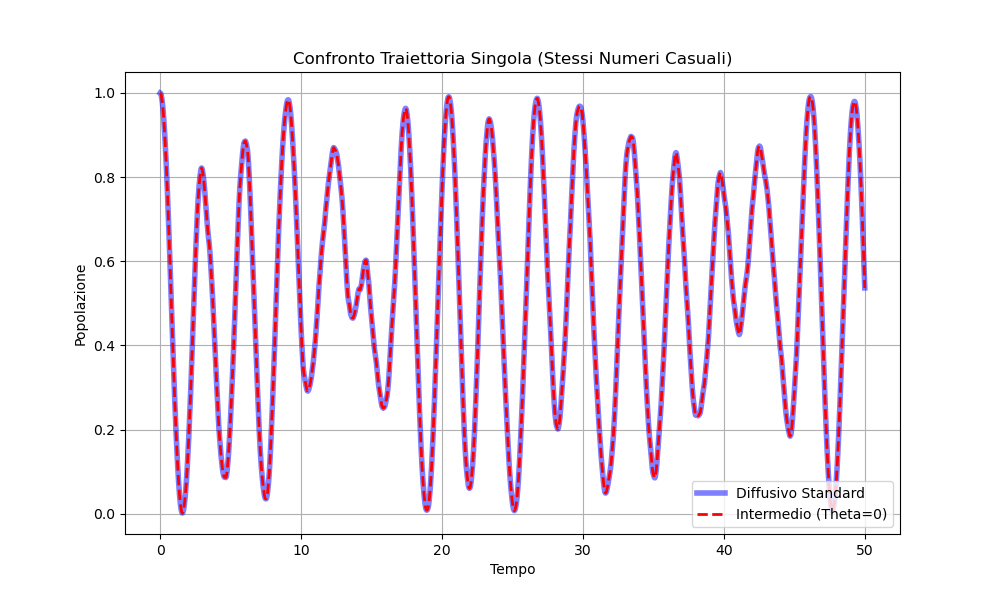

Errore massimo tra le due dinamiche: 1.24e-14
SUCCESS: Le dinamiche sono numericamente identiche!


In [14]:
# 3. Plot di Confronto

plt.figure(figsize=(10, 6))
# Plot solo la prima traiettoria per chiarezza
plt.plot(times, pop_std[:, 0], 'b-', linewidth=4, alpha=0.5, label='Diffusivo Standard')
plt.plot(times, pop_int[:, 0], 'r--', linewidth=2, label='Intermedio (Theta=0)')
plt.title("Confronto Traiettoria Singola (Stessi Numeri Casuali)")
plt.xlabel("Tempo")
plt.ylabel("Popolazione")
plt.legend()
plt.grid()
plt.show()

# Verifica Numerica Finale
error = np.max(np.abs(pop_int - pop_std))
print(f"Errore massimo tra le due dinamiche: {error:.2e}")
if error < 1e-10:
    print("SUCCESS: Le dinamiche sono numericamente identiche!")
else:
    print("WARNING: C'è ancora una differenza.")

## Comparison Trace Evolution

In [15]:
@njit
def compute_density_evolution(rho_initial, U_site, 
                              M0s, M1s,          # Operatori Intermedi
                              U0s, U1s,          # Operatori Standard
                              projectors, n_times, N_site):
    """
    Calcola l'evoluzione 'esatta' della matrice densità per i due metodi.
    Equivale a fare infinite traiettorie (o la traccia sull'ancella).
    """
    # Array per salvare le popolazioni
    pop_trace_int = np.zeros(n_times, dtype=np.float64)
    pop_trace_std = np.zeros(n_times, dtype=np.float64)
    
    # Inizializzazione
    rho_int = rho_initial.copy()
    rho_std = rho_initial.copy()
    
    # Salva stato iniziale
    # Traccia(P * rho)
    pop_trace_int[0] = np.real(np.trace(projectors[1] @ rho_int))
    pop_trace_std[0] = np.real(np.trace(projectors[1] @ rho_std))
    
    for t in range(1, n_times):
        # 1. Evoluzione Unitaria Sistema
        # rho -> U rho U_dag
        U_dag = U_site.conj().T
        rho_int = U_site @ rho_int @ U_dag
        rho_std = U_site @ rho_std @ U_dag
        
        # 2. Collisioni (Mappa CPTP)
        for j in range(N_site):
            # --- A. Metodo Intermedio (Kraus) ---
            # rho_new = M0 rho M0_dag + M1 rho M1_dag
            # Nota: M0_raw contengono già i coefficienti corretti (1/sqrt(2) ecc.)
            # Quindi la somma è automaticamente normalizzata (Traccia = 1)
            term0 = M0s[j] @ rho_int @ M0s[j].conj().T
            term1 = M1s[j] @ rho_int @ M1s[j].conj().T
            rho_int = term0 + term1
            
            # --- B. Metodo Diffusivo Standard ---
            # rho_new = 0.5 * (U0 rho U0_dag + U1 rho U1_dag)
            # Qui la probabilità 1/2 è esplicita
            term0_std = U0s[j] @ rho_std @ U0s[j].conj().T
            term1_std = U1s[j] @ rho_std @ U1s[j].conj().T
            rho_std = 0.5 * (term0_std + term1_std)
            
        # 3. Misura
        pop_trace_int[t] = np.real(np.trace(projectors[1] @ rho_int))
        pop_trace_std[t] = np.real(np.trace(projectors[1] @ rho_std))
        
    return pop_trace_int, pop_trace_std

In [16]:
# ========================================
# Initial wave function and density matrix
# ========================================
# ------
# System
# ------
psi_sys_initial = tensor(basis(2, 0), basis(2, 1)) # I set the population only in site 2   

rho_sys_initial = (ket2dm(psi_sys_initial)).full()       


In [17]:
print("Calcolo evoluzione density matrix (Traccia)...")
pop_trace_int, pop_trace_std = compute_density_evolution(
    rho_sys_initial, U_site_np, 
    M0_raw_arr, M1_raw_arr,  # Usa gli operatori RAW per l'intermedio!
    U0_arr, U1_arr, 
    projectors, n_steps, N_site)

# --- Calcolo Media delle Traiettorie Stocastiche (che hai già calcolato) ---
# Calcoliamo la media sulle traiettorie simulate nel passo precedente
avg_traj_int = np.mean(pop_int, axis=1)
avg_traj_std = np.mean(pop_std, axis=1)

Calcolo evoluzione density matrix (Traccia)...


### Plot

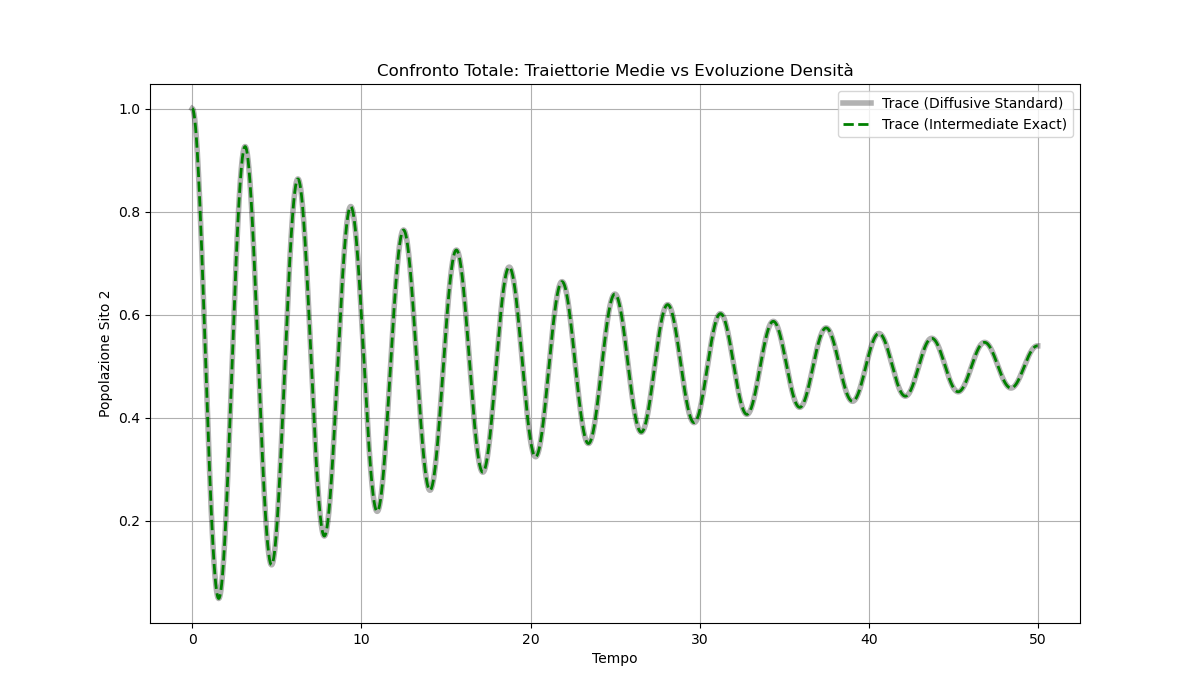

Differenza max tra le due matrici densità: 2.73e-13


In [18]:
plt.figure(figsize=(12, 7))

# 1. Curve Esatte (Matrice Densità) - Linee solide scure
plt.plot(times, pop_trace_std, 'k-', linewidth=4, alpha=0.3, label='Trace (Diffusive Standard)')
plt.plot(times, pop_trace_int, 'g--', linewidth=2, label='Trace (Intermediate Exact)')

plt.title("Confronto Totale: Traiettorie Medie vs Evoluzione Densità")
plt.xlabel("Tempo")
plt.ylabel("Popolazione Sito 2")
plt.legend()
plt.grid(True)
plt.show()

# Verifica Coerenza Tracce
diff_traces = np.max(np.abs(pop_trace_int - pop_trace_std))
print(f"Differenza max tra le due matrici densità: {diff_traces:.2e}")